Project root: e:\github\BTC-and-ETH-Data-Analyst-and-Prediction
Dataset shape:
(7097, 7)

Data types:
Date       object
Asset      object
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
dtype: object

Number of observations by asset:
Asset
BTC-USD    4123
ETH-USD    2974
Name: count, dtype: int64


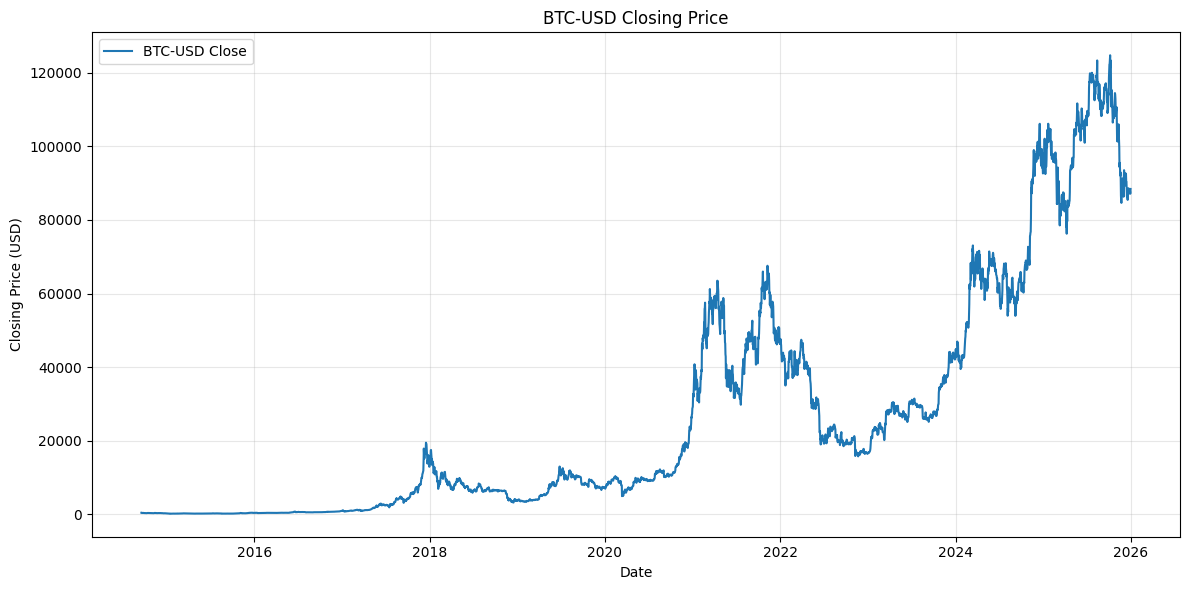

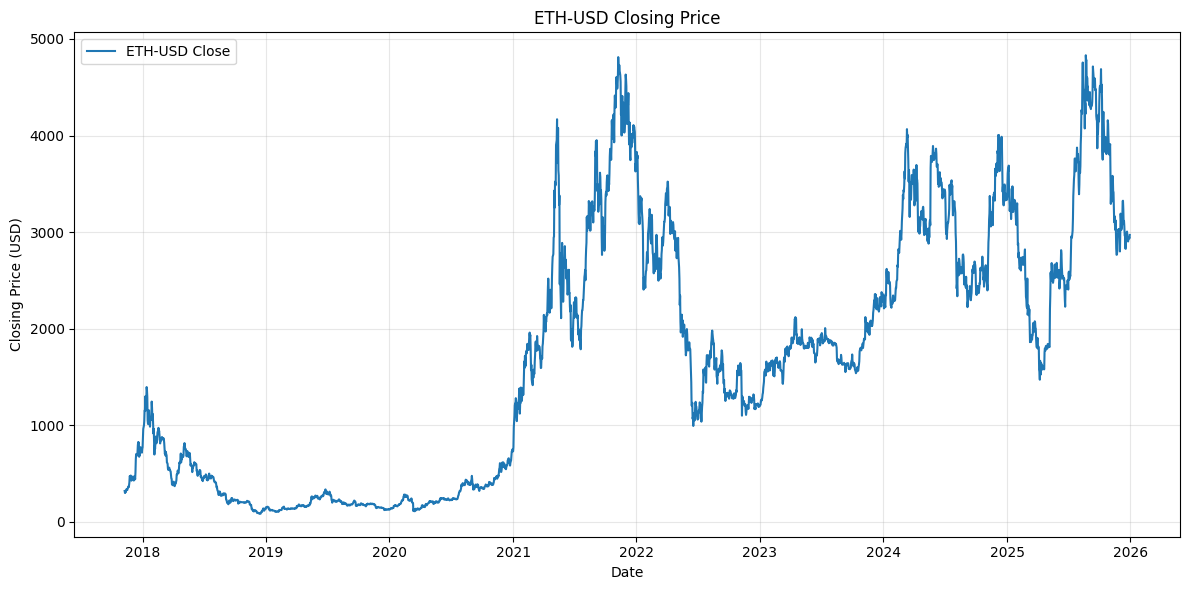

In [1]:
from pathlib import Path
import sys

current_dir = Path.cwd()

if (current_dir / "src").exists():
    PROJECT_ROOT = current_dir
elif (current_dir.parent / "src").exists():
    PROJECT_ROOT = current_dir.parent
else:
    raise FileNotFoundError(
        "Could not locate project root containing 'src'."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)


# ============================================================
# Import libraries
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import (
    clean_market_data,
    generate_quality_report
)


# ============================================================
# Load dataset
# ============================================================

data_path = (
    PROJECT_ROOT
    / "data"
    / "sample"
    / "test_crypto_data.csv"
)

df = pd.read_csv(data_path)

df.head()


# ============================================================
# Basic dataset inspection
# ============================================================

print("Dataset shape:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nNumber of observations by asset:")
print(df["Asset"].value_counts())


# ============================================================
# Data cleaning
# ============================================================

cleaned_df = clean_market_data(df)

quality_report = generate_quality_report(cleaned_df)

quality_report


# ============================================================
# Descriptive statistics
# ============================================================

cleaned_df.groupby("Asset")[
    ["Open", "High", "Low", "Close", "Volume"]
].describe()


# ============================================================
# Closing price visualization
# ============================================================

for asset, asset_df in cleaned_df.groupby("Asset"):

    plt.figure(figsize=(12, 6))

    plt.plot(
        asset_df["Date"],
        asset_df["Close"],
        label=f"{asset} Close"
    )

    plt.title(f"{asset} Closing Price")
    plt.xlabel("Date")
    plt.ylabel("Closing Price (USD)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()